# Building datasets to train an adapter for electricity data

In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import python libraries and kind framework --!

import torch
import numpy as np
from sklearn.model_selection import train_test_split

from matplotlib import pyplot as plt

import utils_data

inf >> read data shape is torch.Size([17420, 7])


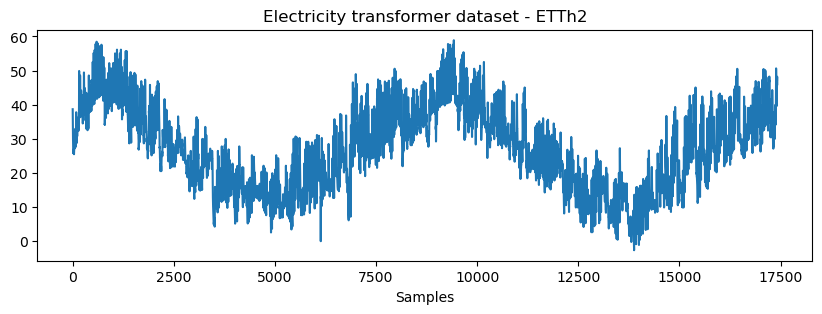

In [2]:
# --! data readout from a file --!

def convert(s):
    """Converts a string ``s`` to a float."""
    return float(s)

def read_detuning(name: str, jcol_read: list[int], nrow_skip: int=0, delim: str=None):
    return torch.tensor(
        np.loadtxt(
            name,
            delimiter=delim,
            skiprows=nrow_skip,
            usecols=jcol_read,
            dtype=np.float32,
            ndmin=2,
            converters=convert))

dataname = '../../data/baselines/ETTh2.csv'
rawdata  = read_detuning(dataname, jcol_read=[1, 2, 3, 4, 5, 6, 7], nrow_skip=1, delim=',')

print(f'inf >> read data shape is {rawdata.shape}')

plt.figure(figsize=(10, 3))
plt.title('Electricity transformer dataset - ETTh2')
plt.plot(rawdata[:, 6])
plt.xlabel('Samples')
plt.show()

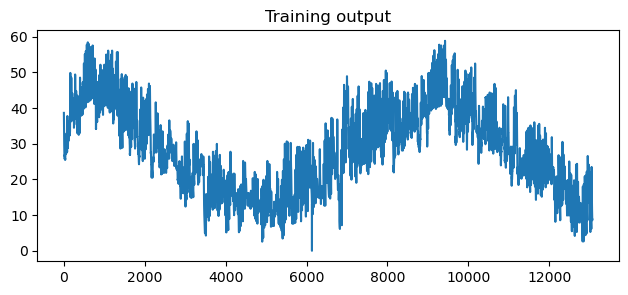

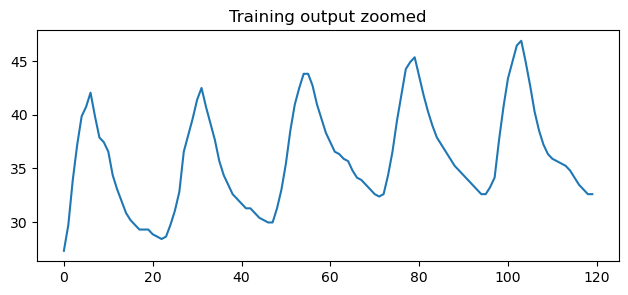

In [10]:
train_i, test_i, train_o, test_o = train_test_split(rawdata[:, :-1], rawdata[:, -1:], shuffle=False)

plt.figure(figsize=(0.75 * 10, 3))
plt.title('Training output')
plt.plot(train_o)
plt.show()

plt.figure(figsize=(0.75 * 10, 3))
plt.title('Training output zoomed')
plt.plot(train_o[2000:2120])
plt.show()

In [4]:
datasaved=False

if datasaved:
    savedata     = torch.cat([train_i, train_o], dim=1).numpy()
    savedir      = '../../data/baselines/et_train_adapter'
    data_nsample = 120
    utils_data.save_traindata([savedata], savedir, data_nsample)